## Installation

First, install Microlensify using pip:

```bash
pip install Microlensify


In [2]:
!pip install Microlensify

DEPRECATION: Loading egg at /Users/atousakalantari/anaconda3/lib/python3.11/site-packages/ticguide-0.5.1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/atousakalantari/anaconda3/lib/python3.11/site-packages/SOMPY-1.1.1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/atousakalantari/anaconda3/lib/python3.11/site-packages/VBBinaryLensing-3.7.0-py3.11-macosx-11.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


# TESS Light Curve Predictions

## Input Format

If you are using URLs of TESS light curves, create a text file containing:

- The URL of each light curve  
- The name of the **flux column**  
- The name of the **time column**

### Example

    https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HLSP/qlp/s0033/0000/0001/2379/3270/hlsp_qlp_tess_ffi_s0033-0000000123793270_tess_v01_llc.fits	SAP_FLUX	TIME


Columns should be separated by spaces or tabs.  
Column names must exactly match those in the FITS file.


## Running Microlensify

To run Microlensify from the command line:

    Microlensify <input_file> <compute_stats> <n_cores>

### Arguments

#### `<input_file>`
Path to the text file containing the list of light curve URLs and their corresponding flux and time column names.

#### `<compute_stats>`

- `yes` — Compute flux statistics (**min, max, median, standard deviation, and std/(max − min)**) directly from the raw flux values.

- `no` — The flux is already normalized (e.g., TESS QLP pipeline flux).  
  In this case, the model uses fixed statistical values derived from the training set.

#### `<n_cores>`

Number of CPU cores to use for parallel processing.


## Example: Gaia Alert (TESS Sector 33)

In [43]:
import pandas as pd

url = pd.read_csv("url_filelist.txt", delim_whitespace=True, header=None)

url.columns = ["url", "time", "flux"]



url



,url,time,flux
0,https://mast.stsci.edu/api/v0.1/Download/file/...,SAP_FLUX,TIME


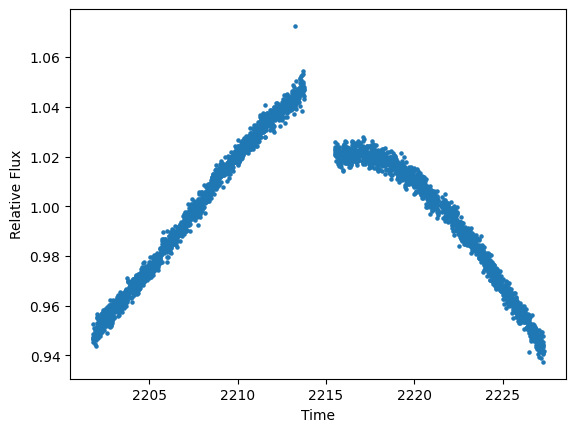

In [44]:
import requests
import io
import matplotlib.pyplot as plt
from astropy.table import Table

# Get the first URL
url = url['url'][0]
table = Table.read(io.BytesIO(requests.get(url).content))

# Keep only rows with QUALITY == 0 if column exists
if 'QUALITY' in table.colnames:
    table = table[table['QUALITY'] == 0]

# Convert to pandas and plot
df = table.to_pandas()
plt.scatter(df['TIME'], df['SAP_FLUX'], s=5)

plt.xlabel('Time')             
plt.ylabel('Relative Flux')    
plt.show()


In [45]:
import Microlensify

# Run Microlensify on normalized QLP flux using 4 CPU cores
!Microlensify "url_filelist.txt" no 1

Loading Microlensify model and scalers...
Model and scalers loaded successfully!

Loaded 1 light curves | compute_stats = no | using 1 threads
Starting predictions... (progress bar below)

Predicting: 100%|█████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.61s/source]

All done! Results saved to → prediction_results.csv


In [46]:
import pandas as pd

df = pd.read_csv("prediction_results.csv")
df.loc[4]

Source               https://mast.stsci.edu/api/v0.1/Download/file/...
Class                                                                1
Probability                                                        1.0
Real_4FWHM_days                                                 51.228
Latent_Space         "0.058445,-0.019965,0.005430,-0.778339,-0.6501...
Points                                                             940
Chunk_Description                               full_downsampled_step3
Name: 4, dtype: object

In [47]:
df1 = df[df['Class']==1].reset_index(drop=True)
df1

,Source,Class,Probability,Real_4FWHM_days,Latent_Space,Points,Chunk_Description
0,https://mast.stsci.edu/api/v0.1/Download/file/...,1,1.0,51.228,"""0.058445,-0.019965,0.005430,-0.778339,-0.6501...",940,full_downsampled_step3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


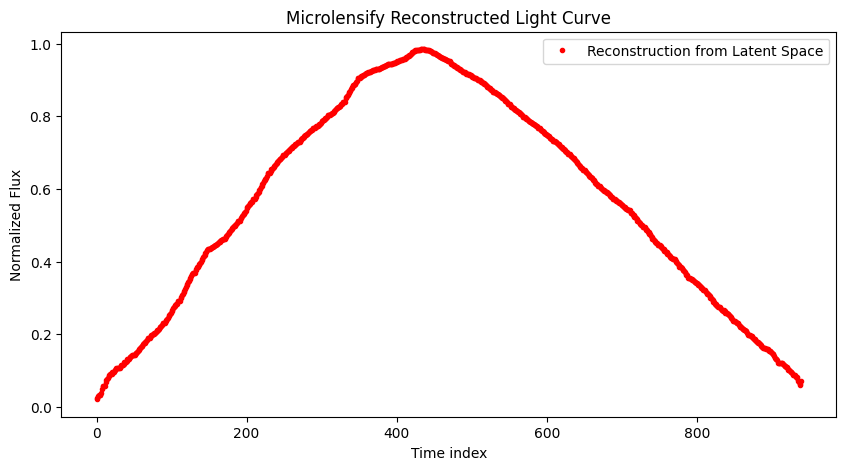

In [17]:
from Microlensify.core import load_model_and_scalers, decoder
import tensorflow as tf
import numpy as np


# Step 1: Load model & scalers
load_model_and_scalers()


latent_str = df1.loc[0, "Latent_Space"]

# Step 4: Convert string to numpy array
z = np.array([float(x) for x in latent_str.strip('"').split(',')]).reshape(1, 20)

# Step 5: Convert to tensor
z_tf = tf.convert_to_tensor(z, dtype=tf.float32)

# Step 6: Reconstruct light curve
reconstructed = decoder.predict(z_tf)  # ONLY latent vector here



        
# Step 7: Plot
plt.figure(figsize=(10,5))

plt.plot(reconstructed[0],'.',color='red', label="Reconstruction from Latent Space")
plt.xlabel("Time index")
plt.ylabel("Normalized Flux")
plt.title("Microlensify Reconstructed Light Curve")
plt.legend()
plt.show()

## Using Local Light Curves

If you have light curves from other surveys (not TESS URLs), you should:

1. Save each light curve's **time** and **flux** columns in a file.
2. Create a **local file list** that contains the paths to these files and the names of the flux & time columns.

### Local Files

A file containing:

- Path to each light curve file  
- Name of the **time column**  
- Name of the **flux column**

### Input File Format

- **Tab-separated** file  
- **Column 1:** time  
- **Column 2:** flux

### Example

```
/path/to/lightcurve1.txt    TIME    FLUX
/path/to/lightcurve2.txt    TIME    SAP_FLUX
```


## Example: OGLE-2018-BLG-0098 with tE = 83.538

In [48]:
import pandas as pd

# Read
df = pd.read_csv("cleaned_OGLE/OGLE-2018-BLG-0098.txt", delim_whitespace=True, header=None)

df.columns = ["time", "flux"]

df



,time,flux
0,2.457425e+06,5460.092498
1,2.457426e+06,5440.013782
2,2.457428e+06,5440.013782
3,2.457429e+06,5425.003216
4,2.457430e+06,5425.003216
...,...,...
3060,2.458413e+06,5510.614111
3061,2.458415e+06,5551.367774
3062,2.458415e+06,5546.257130
3063,2.458416e+06,5490.349610


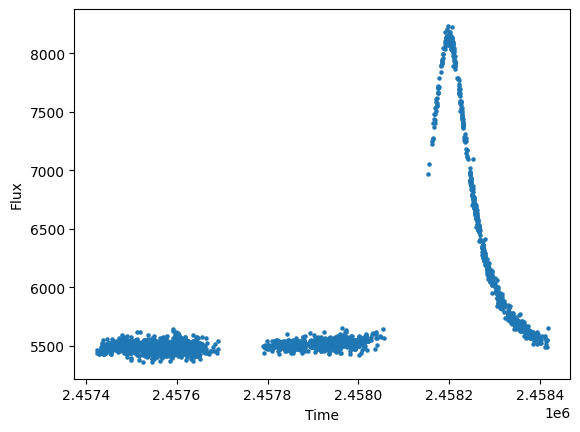

In [49]:
plt.scatter(df['time'], df['flux'], s=5)
plt.xlabel('Time')             
plt.ylabel('Flux')    
plt.show()

list it in your local file input as:

```
cleaned_OGLE/OGLE-2018-BLG-0098.txt    time    flux
```

In [50]:
# predict
import Microlensify

!Microlensify "local_filelist.txt" yes 1

Loading Microlensify model and scalers...
Model and scalers loaded successfully!

Loaded 1 light curves | compute_stats = yes | using 1 threads
Starting predictions... (progress bar below)

Predicting: 100%|█████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.07source/s]

All done! Results saved to → prediction_results.csv


In [53]:
import pandas as pd

df = pd.read_csv("prediction_results.csv")
df

,Source,Class,Probability,Real_4FWHM_days,Latent_Space,Points,Chunk_Description
0,cleaned_OGLE/OGLE-2018-BLG-0098.txt,0,0.0,0.982,"""0.001078,-0.032043,-0.020773,-0.758038,0.5444...",940,win1000_step1_seg0
1,cleaned_OGLE/OGLE-2018-BLG-0098.txt,0,0.0,1.842,"""0.002885,-0.021490,-0.033625,0.015794,0.34159...",940,win1000_step1_seg1
2,cleaned_OGLE/OGLE-2018-BLG-0098.txt,1,1.0,214.403,"""0.049372,-0.011790,-0.035576,-0.354408,-2.751...",940,win1000_step1_seg2
3,cleaned_OGLE/OGLE-2018-BLG-0098.txt,1,1.0,249.825,"""0.021707,-0.031671,-0.016888,-0.824008,-2.185...",940,win1000_end
4,cleaned_OGLE/OGLE-2018-BLG-0098.txt,1,1.0,161.746,"""0.029734,-0.032733,-0.028381,0.930313,-1.4350...",940,full_downsampled_step3
5,cleaned_OGLE/OGLE-2018-BLG-0098.txt,1,1.0,247.544,"""0.021963,-0.031599,-0.017136,-0.816746,-2.205...",940,last1000_fixed


In [55]:
df1 = df[df['Class']==1].reset_index(drop=True)
df1.loc[2]

Source                             cleaned_OGLE/OGLE-2018-BLG-0098.txt
Class                                                                1
Probability                                                        1.0
Real_4FWHM_days                                                161.746
Latent_Space         "0.029734,-0.032733,-0.028381,0.930313,-1.4350...
Points                                                             940
Chunk_Description                               full_downsampled_step3
Name: 2, dtype: object

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


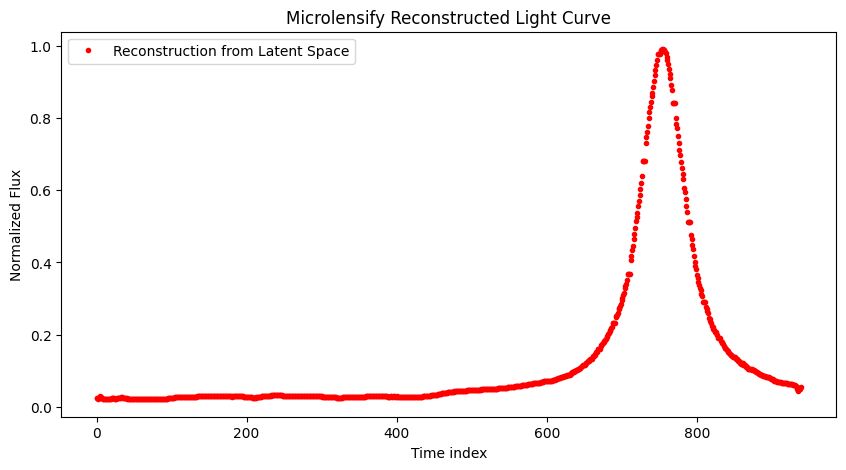

In [23]:
from Microlensify.core import load_model_and_scalers, decoder
import tensorflow as tf
import numpy as np


# Step 1: Load model & scalers
load_model_and_scalers()


latent_str = df1.loc[2, "Latent_Space"]

# Step 4: Convert string to numpy array
z = np.array([float(x) for x in latent_str.strip('"').split(',')]).reshape(1, 20)

# Step 5: Convert to tensor
z_tf = tf.convert_to_tensor(z, dtype=tf.float32)

# Step 6: Reconstruct light curve
reconstructed = decoder.predict(z_tf)  # ONLY latent vector here



        
# Step 7: Plot
plt.figure(figsize=(10,5))

plt.plot(reconstructed[0],'.',color='red', label="Reconstruction from Latent Space")
plt.xlabel("Time index")
plt.ylabel("Normalized Flux")
plt.title("Microlensify Reconstructed Light Curve")
plt.legend()
plt.show()

## Example: ROMAN with tE = 389.1

In [56]:
df = pd.read_csv("w_band_flux_roman.txt", delim_whitespace=True, header=None)

df.columns = ["time", "flux"]

df

,time,flux
0,2.461448e+06,483.749799
1,2.461448e+06,484.469397
2,2.461448e+06,483.929699
3,2.461448e+06,483.749799
4,2.461448e+06,487.887488
...,...,...
41563,2.462980e+06,743.164902
41564,2.462980e+06,721.037261
41565,2.462980e+06,751.800079
41566,2.462980e+06,745.143797


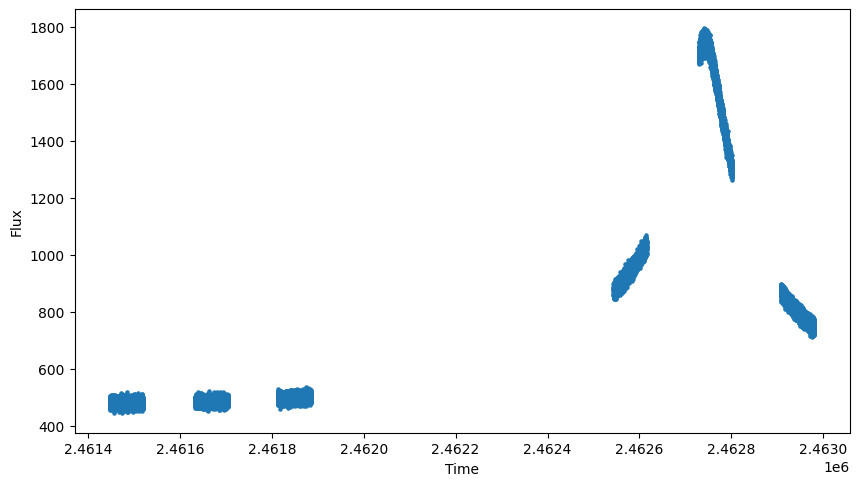

In [57]:
plt.figure(figsize=(10, 5.5))
plt.scatter(df['time'], df['flux'], s=5)
plt.xlabel('Time')             
plt.ylabel('Flux')    
plt.show()

In [58]:
import Microlensify

!Microlensify "roman_filelist.txt" yes 1

Loading Microlensify model and scalers...
Model and scalers loaded successfully!

Loaded 1 light curves | compute_stats = yes | using 1 threads
Starting predictions... (progress bar below)

Predicting: 100%|█████████████████████████████████████████████████| 1/1 [00:12<00:00, 12.78s/source]

All done! Results saved to → prediction_results.csv


In [59]:
import pandas as pd

df = pd.read_csv("prediction_results.csv")
df

,Source,Class,Probability,Real_4FWHM_days,Latent_Space,Points,Chunk_Description
0,w_band_flux_roman.txt,0,0.0,0.073,"""-0.001430,-0.039191,-0.001048,-0.187934,0.973...",940,win1000_step1_seg0
1,w_band_flux_roman.txt,0,0.0,0.066,"""-0.001508,-0.028347,-0.004319,-0.186041,0.883...",940,win1000_step1_seg1
2,w_band_flux_roman.txt,0,0.0,0.073,"""0.003592,-0.026587,-0.011644,-0.166770,0.6117...",940,win1000_step1_seg2
3,w_band_flux_roman.txt,0,0.0,0.052,"""0.014866,-0.032089,-0.019728,-0.181499,0.3944...",940,win1000_step1_seg3
4,w_band_flux_roman.txt,0,0.0,0.082,"""0.016780,-0.048737,0.002298,0.198893,0.637827...",940,win1000_step1_seg4
...,...,...,...,...,...,...,...
156,w_band_flux_roman.txt,0,0.0,2.232,"""0.028246,-0.027161,0.002909,1.336192,-0.11240...",940,win20000_step20_seg0
157,w_band_flux_roman.txt,1,1.0,1598.745,"""0.002637,-0.045030,0.008113,-0.491281,0.18800...",940,win20000_step20_seg1
158,w_band_flux_roman.txt,1,1.0,308.694,"""0.022707,0.049634,-0.058961,-0.928352,0.49976...",940,win20000_end
159,w_band_flux_roman.txt,1,1.0,592.992,"""0.013026,-0.002952,-0.030913,1.734086,-0.4825...",940,full_downsampled_step41


In [60]:
df1 = df[df['Class']==1].reset_index(drop=True)
df1.loc[22]

Source                                           w_band_flux_roman.txt
Class                                                                1
Probability                                                        1.0
Real_4FWHM_days                                                592.992
Latent_Space         "0.013026,-0.002952,-0.030913,1.734086,-0.4825...
Points                                                             940
Chunk_Description                              full_downsampled_step41
Name: 22, dtype: object

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


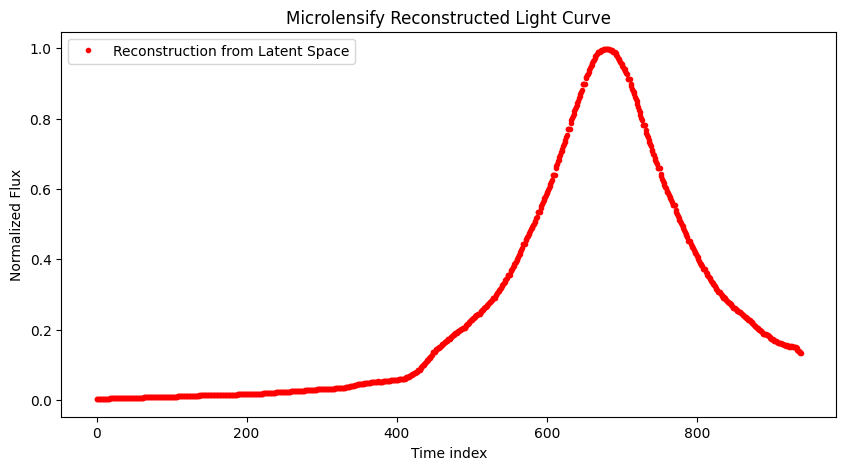

In [41]:
from Microlensify.core import load_model_and_scalers, decoder
import tensorflow as tf
import numpy as np


# Step 1: Load model & scalers
load_model_and_scalers()


latent_str = df1.loc[22, "Latent_Space"]

# Step 4: Convert string to numpy array
z = np.array([float(x) for x in latent_str.strip('"').split(',')]).reshape(1, 20)

# Step 5: Convert to tensor
z_tf = tf.convert_to_tensor(z, dtype=tf.float32)

# Step 6: Reconstruct light curve
reconstructed = decoder.predict(z_tf)  # ONLY latent vector here



        
# Step 7: Plot
plt.figure(figsize=(10,5))

plt.plot(reconstructed[0],'.',color='red', label="Reconstruction from Latent Space")
plt.xlabel("Time index")
plt.ylabel("Normalized Flux")
plt.title("Microlensify Reconstructed Light Curve")
plt.legend()
plt.show()